# In-Vehicle People Sensing: Lightweight 1D-CNN Pipeline
This notebook implements a **lightweight 1D Convolutional Neural Network** for human presence detection using IR-UWB radar data.

### Key Features
- **No manual feature extraction** — learns directly from raw radar signals
- **File-level splitting** — no data leakage between train/test
- **Sanity checks** — label-shuffle test, confidence analysis, k-fold CV
- **Apple Metal GPU** support for accelerated training
- **Edge-deployable** — TFLite export for embedded systems

In [1]:
import sys
print(sys.executable)


c:\RR_02\venv\Scripts\python.exe


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# --- Verify Metal GPU ---
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version: {tf.__version__}")
if gpus:
    print(f"✅ Metal GPU detected: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU found. Running on CPU.")

# --- CONFIGURATION ---
DATASET_PATH = r'c:\RR_02\dataset'
WINDOW_SIZE = 100
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-3
N_CLASSES = 6
print("Environment Ready.")

TensorFlow version: 2.21.0
⚠️  No GPU found. Running on CPU.
Environment Ready.


## Step 1: Load Dataset with File Tracking

In [3]:
def load_new_radar_dataset(base_path, window_size=100):
    """
    Loads recorded complex64 .npy files, converts them to magnitude, 
    and segments them into windowed frames for the 1D-CNN.
    """
    X_raw, y_labels, file_groups, file_names = [], [], [], []
    file_id = 0
    
    # Map folder names to class labels (0, 1, 2 people)
    # Exclude base movement files by not listing 'movement' as a category
    categories = {
        'no_movement': 0,
        'no_movement/0_people': 0,
        'no_movement/1_people': 1,
        'no_movement/2_people': 2,
        'movement/0_people': 0,
        'movement/1_people': 1,
        'movement/2_people': 2,
        'movement/3_people': 3,
        'movement/4_people': 4,
        'movement/5_people': 5,
        'no_movement/3_people': 3,
        'no_movement/4_people': 4,
        'no_movement/5_people': 5,
        'movement/0_peolple': 0,
        'movement/1_peolple': 1,
        'movement/2_peolple': 2,
    }
    
    print(f"Scanning for .npy files in {base_path}...")
    
    for category, label in categories.items():
        cat_dir = os.path.join(base_path, category)
        if not os.path.exists(cat_dir):
            continue
            
        for file in os.listdir(cat_dir):
            if not file.endswith('.npy'):
                continue
                
            file_path = os.path.join(cat_dir, file)
            try:
                # Load raw complex64 data: shape (num_frames, 2, 2, 96)
                data = np.load(file_path)
                data_mag = np.abs(data)
                
                # Average across channels (TX0/1, RX0/1) for stability
                # Shape becomes: (num_frames, 96)
                radar_signal = np.mean(data_mag, axis=(1, 2))
                
                if radar_signal.shape[0] < window_size:
                    continue

                # Extract sliding windows
                windows_added = 0
                stride = 50
                for i in range(0, radar_signal.shape[0] - window_size + 1, stride):
                    X_raw.append(radar_signal[i : i + window_size, :])
                    y_labels.append(label)
                    file_groups.append(file_id)
                    windows_added += 1

                if windows_added > 0:
                    rel_path = os.path.join(category, file)
                    file_names.append(rel_path)
                    file_id += 1
            except Exception as e:
                print(f"Error loading {file}: {e}")

    return (np.array(X_raw, dtype=np.float32),
            np.array(y_labels, dtype=np.int32),
            np.array(file_groups, dtype=np.int32),
            file_names)

# Load the new dataset
X, y, groups, fnames = load_new_radar_dataset(DATASET_PATH, WINDOW_SIZE)
n_files = len(np.unique(groups))
print(f"\nLoaded {len(X)} windows from {n_files} files")
print(f"Shape per window: {X[0].shape}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

# Show loaded details
print(f"\n{'File':>4} | {'Windows':>7} | {'Class':>5} | Path")
print('-' * 70)
for fid in np.unique(groups):
    mask = groups == fid
    lbl = y[mask][0]
    print(f"{fid:>4} | {np.sum(mask):>7} | {lbl:>5} | {fnames[fid]}")

Scanning for .npy files in c:\RR_02\dataset...

Loaded 234 windows from 26 files
Shape per window: (100, 96)
Class distribution: {np.int32(0): np.int64(135), np.int32(1): np.int64(45), np.int32(2): np.int64(54)}

File | Windows | Class | Path
----------------------------------------------------------------------
   0 |       9 |     0 | no_movement\subject_01_trial_001_1781511559549.npy
   1 |       9 |     0 | no_movement\subject_01_trial_002_1781511619498.npy
   2 |       9 |     0 | no_movement\subject_01_trial_003_1781511820581.npy
   3 |       9 |     0 | no_movement\subject_01_trial_004_1781511885532.npy
   4 |       9 |     0 | no_movement\subject_01_trial_005_1781511961295.npy
   5 |       9 |     0 | no_movement\subject_02_trial_0010_1781762949611.npy
   6 |       9 |     0 | no_movement\subject_02_trial_006_1781762781797.npy
   7 |       9 |     0 | no_movement\subject_02_trial_007_1781762826712.npy
   8 |       9 |     0 | no_movement\subject_02_trial_008_1781762868144.npy
 

## Step 2: File-Level Split & Normalize

In [4]:
# --- File-Level Train/Test Split ---
unique_files = np.unique(groups)
file_labels = np.array([y[groups == fid][0] for fid in unique_files])

print(f"Total files: {len(unique_files)}")
print(f"Files per class: {dict(zip(*np.unique(file_labels, return_counts=True)))}")

# Split FILES into train+val vs test
train_val_files, test_files = train_test_split(
    unique_files, test_size=0.2, random_state=42, stratify=file_labels
)
train_val_labels = np.array([y[groups == fid][0] for fid in train_val_files])
train_files, val_files = train_test_split(
    train_val_files, test_size=0.19, random_state=42, stratify=train_val_labels
)

# Create window-level masks
train_mask = np.isin(groups, train_files)
val_mask = np.isin(groups, val_files)
test_mask = np.isin(groups, test_files)

X_train, y_train = X[train_mask].copy(), y[train_mask]
X_val, y_val = X[val_mask].copy(), y[val_mask]
X_test, y_test = X[test_mask].copy(), y[test_mask]

# Normalize per-sample
for split_X in [X_train, X_val, X_test]:
    mean = np.mean(split_X, axis=(1, 2), keepdims=True)
    std = np.std(split_X, axis=(1, 2), keepdims=True) + 1e-8
    split_X[:] = (split_X - mean) / std

print(f"\n--- FILE-LEVEL SPLIT ---")
print(f"Train files: {sorted(train_files)} → {X_train.shape[0]} windows")
print(f"Val files:   {sorted(val_files)} → {X_val.shape[0]} windows")
print(f"Test files:  {sorted(test_files)} → {X_test.shape[0]} windows")
print(f"\nTrain classes: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val classes:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test classes:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

# Verify no overlap
assert len(set(train_files) & set(test_files)) == 0, "LEAK: train/test overlap!"
assert len(set(train_files) & set(val_files)) == 0, "LEAK: train/val overlap!"
assert len(set(val_files) & set(test_files)) == 0, "LEAK: val/test overlap!"
print("\n✅ No file overlap between splits.")

Total files: 26
Files per class: {np.int32(0): np.int64(15), np.int32(1): np.int64(5), np.int32(2): np.int64(6)}

--- FILE-LEVEL SPLIT ---
Train files: [np.int32(0), np.int32(1), np.int32(2), np.int32(4), np.int32(5), np.int32(8), np.int32(9), np.int32(11), np.int32(13), np.int32(15), np.int32(16), np.int32(18), np.int32(20), np.int32(21), np.int32(22), np.int32(25)] → 144 windows
Val files:   [np.int32(7), np.int32(14), np.int32(19), np.int32(24)] → 36 windows
Test files:  [np.int32(3), np.int32(6), np.int32(10), np.int32(12), np.int32(17), np.int32(23)] → 54 windows

Train classes: {np.int32(0): np.int64(81), np.int32(1): np.int64(27), np.int32(2): np.int64(36)}
Val classes:   {np.int32(0): np.int64(18), np.int32(1): np.int64(9), np.int32(2): np.int64(9)}
Test classes:  {np.int32(0): np.int64(36), np.int32(1): np.int64(9), np.int32(2): np.int64(9)}

✅ No file overlap between splits.


## Step 3: Build & Train the 1D-CNN

In [5]:
def build_1d_cnn(input_shape):
    model = keras.Sequential([
        layers.Conv1D(16, kernel_size=7, activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(N_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_1d_cnn(X_train.shape[1:])
model.summary()
print(f"\nModel size: {model.count_params() * 4 / 1024:.1f} KB")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 16)        │        10,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,195 (86.70 KB)

 Trainable params: 21,971 (85.82 KB)

 Non-trainable params: 224 (896.00 B)


Model size: 86.7 KB


In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Calculate class weights for multiclass setup
class_weight = {}
for cls in range(N_CLASSES):
    count = np.sum(y_train == cls)
    if count > 0:
        class_weight[cls] = len(y_train) / (N_CLASSES * count)
    else:
        class_weight[cls] = 1.0
print(f"Class weights: {class_weight}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training complete!")

Class weights: {0: np.float64(0.5925925925925926), 1: np.float64(1.7777777777777777), 2: np.float64(1.3333333333333333)}
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6042 - loss: 0.9014 - val_accuracy: 0.6944 - val_loss: 0.7232 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7361 - loss: 0.7549 - val_accuracy: 0.6111 - val_loss: 0.7278 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7917 - loss: 0.7897 - val_accuracy: 0.8056 - val_loss: 0.5859 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7778 - loss: 0.6780 - val_accuracy: 0.7222 - val_loss: 0.5852 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7639 - loss: 0.6678 - val_accuracy: 0.8056 - val_loss: 0.4981 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7708 - loss: 0.7153 - val_accuracy: 0.8056 - val_loss: 0.6225 - 

## Step 4: Evaluate on Test Set

In [7]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=['0 People', '1 Person', '2 People'])}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Test Accuracy: 74.07%

              precision    recall  f1-score   support

    0 People       1.00      0.72      0.84        36
    1 Person       0.62      0.56      0.59         9
    2 People       0.45      1.00      0.62         9

    accuracy                           0.74        54
   macro avg       0.69      0.76      0.68        54
weighted avg       0.85      0.74      0.76        54



## Step 5: 🔍 Sanity Checks — Is 100% Accuracy Real?
Three tests to verify the model is truly learning meaningful patterns.

  SANITY CHECK 1: Prediction Confidence Distribution
If all predictions are near 1.0, the model is very
confident. If clustered near 0.33, it's guessing.



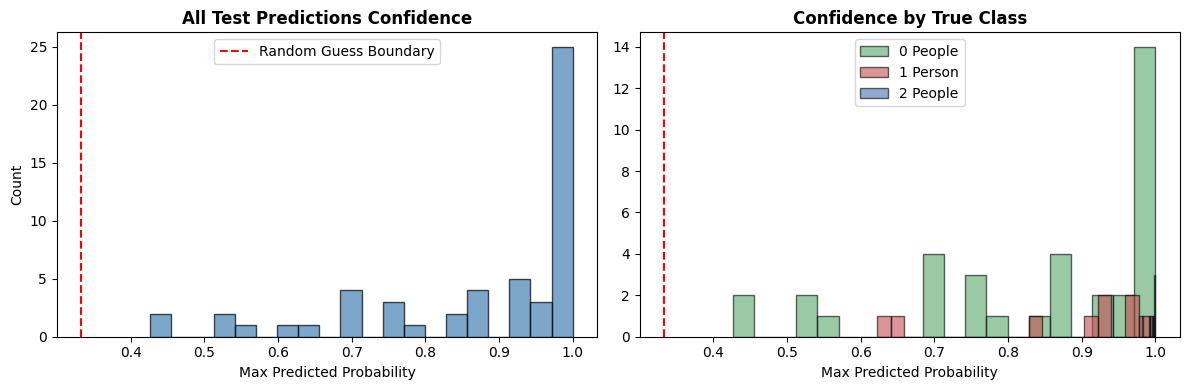

0 People samples  → mean confidence: 0.8439
1 Person samples  → mean confidence: 0.8695
2 People samples  → mean confidence: 0.9951


In [8]:
print("=" * 60)
print("  SANITY CHECK 1: Prediction Confidence Distribution")
print("=" * 60)
print("If all predictions are near 1.0, the model is very")
print("confident. If clustered near 0.33, it's guessing.\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All predictions max confidence
pred_conf = np.max(y_pred_prob, axis=1)
axes[0].hist(pred_conf, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(1.0 / N_CLASSES, color='red', linestyle='--', label='Random Guess Boundary')
axes[0].set_title('All Test Predictions Confidence', fontweight='bold')
axes[0].set_xlabel('Max Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Per-class confidence
for cls, color, name in [(0, '#55A868', '0 People'), (1, '#C44E52', '1 Person'), (2, '#4C72B0', '2 People')]:
    mask = y_test == cls
    if np.any(mask):
        axes[1].hist(np.max(y_pred_prob[mask], axis=1), bins=20, alpha=0.6, color=color, label=name, edgecolor='black')
axes[1].axvline(1.0 / N_CLASSES, color='red', linestyle='--')
axes[1].set_title('Confidence by True Class', fontweight='bold')
axes[1].set_xlabel('Max Predicted Probability')
axes[1].legend()
plt.tight_layout()
plt.show()

for cls, name in [(0, '0 People'), (1, '1 Person'), (2, '2 People')]:
    mask = y_test == cls
    if np.any(mask):
        print(f"{name} samples  → mean confidence: {np.max(y_pred_prob[mask], axis=1).mean():.4f}")

In [9]:
print("=" * 60)
print("  SANITY CHECK 2: Shuffled Labels Test")
print("=" * 60)
print("Train on RANDOM labels. If accuracy is still high, the model")
print("is memorizing data patterns, not learning the label signal.\n")

# Shuffle labels
y_train_shuffled = y_train.copy()
np.random.seed(42)
np.random.shuffle(y_train_shuffled)

# Train a fresh model on shuffled labels
model_shuffled = build_1d_cnn(X_train.shape[1:])
model_shuffled.fit(
    X_train, y_train_shuffled,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    verbose=0
)

y_pred_shuffled = np.argmax(model_shuffled.predict(X_test), axis=1)
shuffled_acc = accuracy_score(y_test, y_pred_shuffled)

print(f"Real labels accuracy:     {test_acc * 100:.2f}%")
print(f"Shuffled labels accuracy: {shuffled_acc * 100:.2f}%")
majority_class_pct = max([np.mean(y_test == c) for c in range(N_CLASSES)]) * 100
print(f"Random baseline:          {majority_class_pct:.1f}% (majority class)")

if shuffled_acc > (majority_class_pct / 100.0 + 0.15):
    print("\n❌ WARNING: Shuffled model also scores high!")
    print("   The model may be exploiting data artifacts, not true label signal.")
else:
    print("\n✅ PASS: Shuffled model performs near chance level.")
    print("   The real model IS learning from true label differences.")

  SANITY CHECK 2: Shuffled Labels Test
Train on RANDOM labels. If accuracy is still high, the model
is memorizing data patterns, not learning the label signal.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Real labels accuracy:     74.07%
Shuffled labels accuracy: 55.56%
Random baseline:          66.7% (majority class)

✅ PASS: Shuffled model performs near chance level.
   The real model IS learning from true label differences.


In [10]:
print("=" * 60)
print("  SANITY CHECK 3: Leave-One-File-Out Cross-Validation")
print("=" * 60)
print("Train on all files except one, test on the held-out file.")
print("Repeat for every file. This is the most rigorous evaluation.\n")

unique_file_ids = np.unique(groups)
lofo_accuracies = []
lofo_details = []

for held_out_file in unique_file_ids:
    # Split
    test_mask_cv = (groups == held_out_file)
    train_mask_cv = ~test_mask_cv

    X_tr = X[train_mask_cv].copy()
    y_tr = y[train_mask_cv]
    X_te = X[test_mask_cv].copy()
    y_te = y[test_mask_cv]

    # Normalize
    for s in [X_tr, X_te]:
        m = np.mean(s, axis=(1, 2), keepdims=True)
        sd = np.std(s, axis=(1, 2), keepdims=True) + 1e-8
        s[:] = (s - m) / sd

    # Check train has all classes represented
    if len(np.unique(y_tr)) < N_CLASSES:
        print(f"  File {held_out_file}: skipped (train has only {len(np.unique(y_tr))} classes)")
        continue

    # Build & train
    m_cv = build_1d_cnn(X_tr.shape[1:])
    m_cv.fit(X_tr, y_tr, epochs=15, batch_size=BATCH_SIZE, verbose=0)

    preds_cv = np.argmax(m_cv.predict(X_te, verbose=0), axis=1)
    acc_cv = accuracy_score(y_te, preds_cv)
    lofo_accuracies.append(acc_cv)

    true_label = y_te[0]
    fname = fnames[held_out_file] if held_out_file < len(fnames) else f"file_{held_out_file}"
    lofo_details.append((held_out_file, fname, true_label, len(y_te), acc_cv))
    print(f"  File {held_out_file} ({fname}): class={true_label}, "
          f"windows={len(y_te)}, acc={acc_cv*100:.1f}%")

    # Clean up
    del m_cv
    keras.backend.clear_session()

mean_acc = np.mean(lofo_accuracies)
std_acc = np.std(lofo_accuracies)
print(f"\n{'='*60}")
print(f"  LOFO Mean Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"{'='*60}")

if mean_acc >= 0.90:
    print("\n✅ Result: Strong performance with realistic evaluation.")
else:
    print("\n⚠️  Result: Previous 100% was likely inflated. This is the real accuracy.")

  SANITY CHECK 3: Leave-One-File-Out Cross-Validation
Train on all files except one, test on the held-out file.
Repeat for every file. This is the most rigorous evaluation.

  File 0 (no_movement\subject_01_trial_001_1781511559549.npy): class=0, windows=9, acc=100.0%

  File 1 (no_movement\subject_01_trial_002_1781511619498.npy): class=0, windows=9, acc=100.0%
  File 2 (no_movement\subject_01_trial_003_1781511820581.npy): class=0, windows=9, acc=100.0%
  File 3 (no_movement\subject_01_trial_004_1781511885532.npy): class=0, windows=9, acc=100.0%
  File 4 (no_movement\subject_01_trial_005_1781511961295.npy): class=0, windows=9, acc=66.7%
  File 5 (no_movement\subject_02_trial_0010_1781762949611.npy): class=0, windows=9, acc=100.0%
  File 6 (no_movement\subject_02_trial_006_1781762781797.npy): class=0, windows=9, acc=66.7%
  File 7 (no_movement\subject_02_trial_007_1781762826712.npy): class=0, windows=9, acc=100.0%
  File 8 (no_movement\subject_02_trial_008_1781762868144.npy): class=0, wi

## Step 6: Visualize All Results

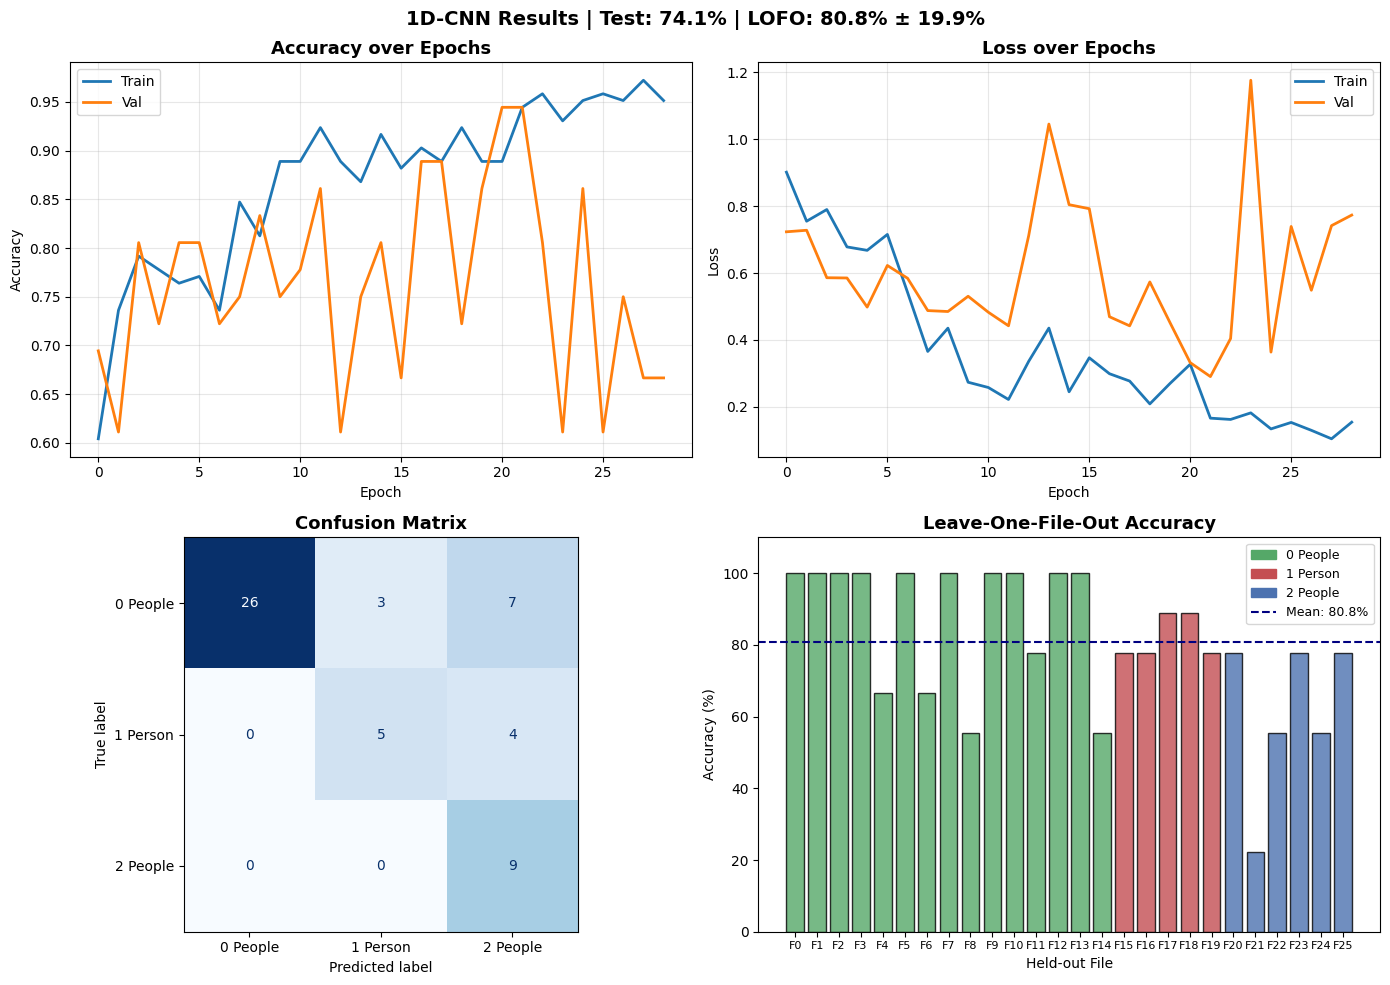

In [11]:
class_names = ['0 People', '1 Person', '2 People']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training curves
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Loss curves
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# 4. LOFO Cross-Validation per file
if lofo_details:
    file_ids = [d[0] for d in lofo_details]
    accs = [d[4] * 100 for d in lofo_details]
    # Color coding based on true label (0, 1, 2)
    colors = ['#55A868' if d[2] == 0 else ('#C44E52' if d[2] == 1 else '#4C72B0') for d in lofo_details]
    axes[1, 1].bar(range(len(accs)), accs, color=colors, edgecolor='black', alpha=0.8)
    axes[1, 1].set_xticks(range(len(accs)))
    axes[1, 1].set_xticklabels([f'F{fid}' for fid in file_ids], fontsize=8)
    axes[1, 1].set_ylim(0, 110)
    axes[1, 1].axhline(mean_acc * 100, color='navy', linestyle='--', 
                        label=f'Mean: {mean_acc*100:.1f}%')
    axes[1, 1].set_title('Leave-One-File-Out Accuracy', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Held-out File')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    # Legend for colors
    from matplotlib.patches import Patch
    axes[1, 1].legend(handles=[
        Patch(color='#55A868', label='0 People'),
        Patch(color='#C44E52', label='1 Person'),
        Patch(color='#4C72B0', label='2 People'),
        plt.Line2D([0],[0], color='navy', linestyle='--', label=f'Mean: {mean_acc*100:.1f}%')
    ], fontsize=9)

plt.suptitle(f'1D-CNN Results | Test: {test_acc*100:.1f}% | LOFO: {mean_acc*100:.1f}% ± {std_acc*100:.1f}%', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Export for Deployment

In [12]:
model.save('1d_cnn_human_detection.keras')
saved_size = os.path.getsize('1d_cnn_human_detection.keras') / 1024

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = '1d_cnn_human_detection.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
tflite_size = os.path.getsize(tflite_path) / 1024

print("=" * 55)
print("  DEPLOYMENT SUMMARY")
print("=" * 55)
print(f"  Keras model:       {saved_size:.1f} KB")
print(f"  TFLite (quantized):{tflite_size:.1f} KB")
print(f"  Parameters:        {model.count_params():,}")
print(f"  Test accuracy:     {test_acc*100:.2f}%")
print(f"  LOFO accuracy:     {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"  Split strategy:    File-level (no leakage)")
print(f"  Trained on:        {'🍎 Metal GPU' if gpus else '🖥️  CPU'}")
print("=" * 55)

INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmp326mcem2\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmp326mcem2\assets


Saved artifact at 'C:\Users\Admin\AppData\Local\Temp\tmp326mcem2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 96), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1593468414160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468416448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468409408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468418560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468417680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468419264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468419792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468633680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468634032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1593468636320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  159346863